(linear_algebra)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 线性代数

```{index} single: Linear Algebra
```

```{contents} 目录
:depth: 2
```

## 概述

线性代数是经济学家最值得投入学习的应用数学分支之一。

例如，经济学和金融学中的许多应用问题都需要求解线性方程组，比如

$$
\begin{aligned}
    y_1 = a x_1 + b x_2 \\
    y_2 = c x_1 + d x_2
\end{aligned}
$$

或者更一般地，

```{math}
:label: la_se

\begin{aligned}
    y_1 = a_{11} x_1 + a_{12} x_2 + \cdots + a_{1k} x_k \\
    \vdots  \\
    y_n = a_{n1} x_1 + a_{n2} x_2 + \cdots + a_{nk} x_k
\end{aligned}
```

这里的目标是在已知 $a_{11}, \ldots, a_{nk}$ 和 $y_1, \ldots, y_n$ 的情况下，求解"未知数" $x_1, \ldots, x_k$。

在研究这类问题时，我们需要考虑以下几个基本问题:

* 这个方程组是否有解?
* 如果有解,解是唯一的吗？如果有多个解,这意味着什么?
* 如果没有精确解,是否可以找到一个最优的近似解?
* 如果解存在,有什么有效的方法可以求出它?

这些都是线性代数所要解决的问题。

本讲将介绍线性代数和矩阵运算的基础知识。

我们将同时关注理论基础和实际计算。

虽然本讲与我们在[之前的讲座](https://python-programming.quantecon.org/numpy.html)中已经介绍过NumPy数组的基本操作有所重合，但这里我们将从更理论的角度来探讨线性代数。

请注意，本讲比大多数讲座更偏重理论，其中包含的背景知识将在我们后续的应用中逐步用到。

让我们从一些导入开始：

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"
mpl.font_manager.fontManager.addfont(FONTPATH)
plt.rcParams['font.family'] = ['Source Han Serif SC']

plt.rcParams["figure.figsize"] = (11, 5)  #设置默认图形大小
import numpy as np
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import inv, solve, det, eig

## {index}`向量 <single: Vectors>`

```{index} single: Linear Algebra; Vectors
```

长度为$n$的*向量*就是一个由$n$个数字组成的序列（或数组、元组），我们将其写作$x = (x_1, \ldots, x_n)$或$x = [x_1, \ldots, x_n]$。

我们可以根据需要将这些序列横向或纵向书写。

（在后面讨论矩阵运算时，区分横向和纵向表示将变得很重要）

我们用$\mathbb R^n$表示所有$n$维向量的集合。

以$\mathbb R^2$为例，它代表二维平面，其中的每个向量都对应平面上的一个点。

在传统上，向量在视觉上被表示为从原点指向该点的箭头。

下图以这种方式展示了三个向量

findfont: Failed to find font weight normal, now using 600.


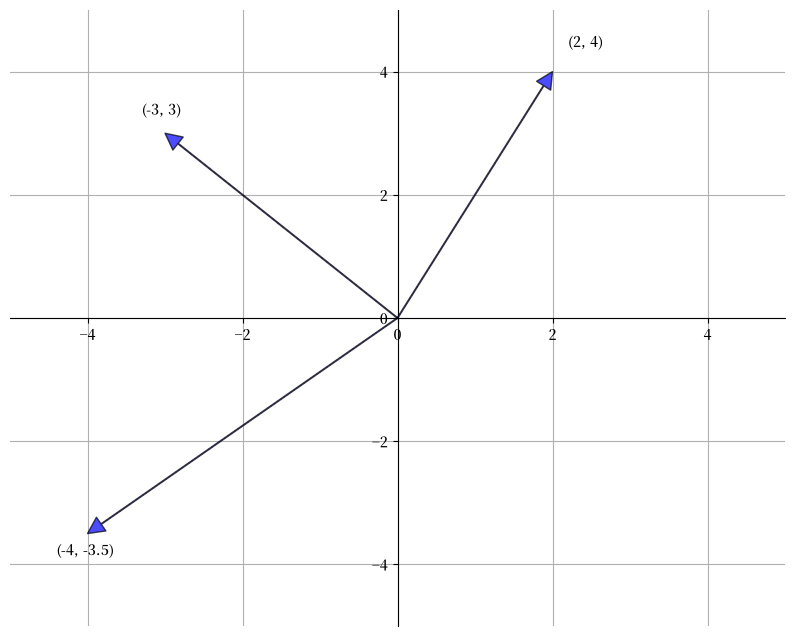

In [2]:
fig, ax = plt.subplots(figsize=(10, 8))
# 设置通过原点的轴
for spine in ['left', 'bottom']:
    ax.spines[spine].set_position('zero')
for spine in ['right', 'top']:
    ax.spines[spine].set_color('none')

ax.set(xlim=(-5, 5), ylim=(-5, 5))
ax.grid()
vecs = ((2, 4), (-3, 3), (-4, -3.5))
for v in vecs:
    ax.annotate('', xy=v, xytext=(0, 0),
                arrowprops=dict(facecolor='blue',
                shrink=0,
                alpha=0.7,
                width=0.5))
    ax.text(1.1 * v[0], 1.1 * v[1], str(v))
plt.show()

### 向量运算

```{index} single: Vectors; Operations
```

向量最常见的两种运算是加法和标量乘法，下面我们来介绍。

根据定义，当我们对两个向量进行加法运算时，我们是按元素逐个相加

$$
x + y =
\begin{bmatrix}
    x_1 \\
    x_2 \\
    \vdots \\
    x_n
\end{bmatrix} +
\begin{bmatrix}
     y_1 \\
     y_2 \\
    \vdots \\
     y_n
\end{bmatrix} :=
\begin{bmatrix}
    x_1 + y_1 \\
    x_2 + y_2 \\
    \vdots \\
    x_n + y_n
\end{bmatrix}
$$

标量乘法是一种将数字 $\gamma$ 与向量 $x$ 相乘的运算，得到

$$
\gamma x :=
\begin{bmatrix}
    \gamma x_1 \\
    \gamma x_2 \\
    \vdots \\
    \gamma x_n
\end{bmatrix}
$$

下图展示了标量乘法

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


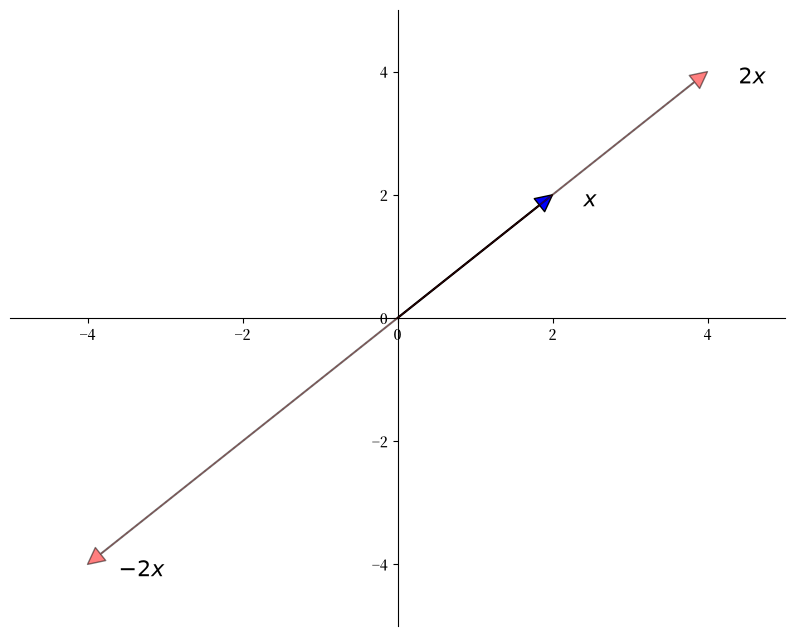

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))
# Set the axes through the origin
for spine in ['left', 'bottom']:
    ax.spines[spine].set_position('zero')
for spine in ['right', 'top']:
    ax.spines[spine].set_color('none')

ax.set(xlim=(-5, 5), ylim=(-5, 5))
x = (2, 2)
ax.annotate('', xy=x, xytext=(0, 0),
            arrowprops=dict(facecolor='blue',
            shrink=0,
            alpha=1,
            width=0.5))
ax.text(x[0] + 0.4, x[1] - 0.2, '$x$', fontsize='16')


scalars = (-2, 2)
x = np.array(x)

for s in scalars:
    v = s * x
    ax.annotate('', xy=v, xytext=(0, 0),
                arrowprops=dict(facecolor='red',
                shrink=0,
                alpha=0.5,
                width=0.5))
    ax.text(v[0] + 0.4, v[1] - 0.2, f'${s} x$', fontsize='16')
plt.show()

在Python中，向量可以用列表或元组来表示，例如 `x = (2, 4, 6)`，但更常见的是用[NumPy数组](https://python-programming.quantecon.org/numpy.html#numpy-arrays)来表示。

NumPy数组的一个优点是标量乘法和加法具有非常自然的语法

In [4]:
x = np.ones(3)            # 创建一个包含三个1的向量
y = np.array((2, 4, 6))   # 将元组(2, 4, 6)转换为数组
x + y

array([3., 5., 7.])

In [5]:
4 * x

array([4., 4., 4.])

### 内积和范数

```{index} single: Vectors; Inner Product
```

```{index} single: Vectors; Norm
```

向量 $x,y \in \mathbb R ^n$ 的*内积*定义为

$$
x' y := \sum_{i=1}^n x_i y_i
$$

如果两个向量的内积为零，则称这两个向量*正交*。

向量 $x$ 的*范数*表示其"长度"（即其与零向量的距离），定义为

$$
\| x \| := \sqrt{x' x} := \left( \sum_{i=1}^n x_i^2 \right)^{1/2}
$$

表达式 $\| x - y\|$ 被理解为 $x$ 和 $y$ 之间的距离。

继续前面的例子，内积和范数可以按如下方式计算

In [6]:
np.sum(x * y)          # x和y的内积，方法1

np.float64(12.0)

In [7]:
x @ y                  # x和y的内积，方法2（推荐）

np.float64(12.0)

推荐使用`@`运算符，因为它使用了经过优化的BLAS库来实现乘加融合运算，相比分别进行乘法和求和运算，具有更好的性能和数值精度。

In [8]:
np.sqrt(np.sum(x**2))  # x的范数，方法1

np.float64(1.7320508075688772)

In [9]:
np.sqrt(x @ x)         # x的范数，方法2（推荐）

np.float64(1.7320508075688772)

In [10]:
np.linalg.norm(x)      # x的范数，方法3

np.float64(1.7320508075688772)

### 张成空间

```{index} single: Vectors; Span
```

给定$\mathbb R ^n$中的一组向量$A := \{a_1, \ldots, a_k\}$，我们自然会思考通过执行线性运算可以创建哪些新向量。

以这种方式创建的新向量被称为$A$的*线性组合*。

具体来说，如果$y \in \mathbb R ^n$是$A := \{a_1, \ldots, a_k\}$的线性组合，那么

$$
y = \beta_1 a_1 + \cdots + \beta_k a_k
\text{ 其中 } \beta_1, \ldots, \beta_k \text{ 为某些标量}
$$

在这种情况下，值$\beta_1, \ldots, \beta_k$被称为线性组合的*系数*。

$A$的所有线性组合构成的集合被称为$A$的*张成空间*。

下图显示了$\mathbb R ^3$中$A = \{a_1, a_2\}$的张成空间。

张成空间是一个通过这两个点和原点的二维平面。

(la_3dvec)=

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


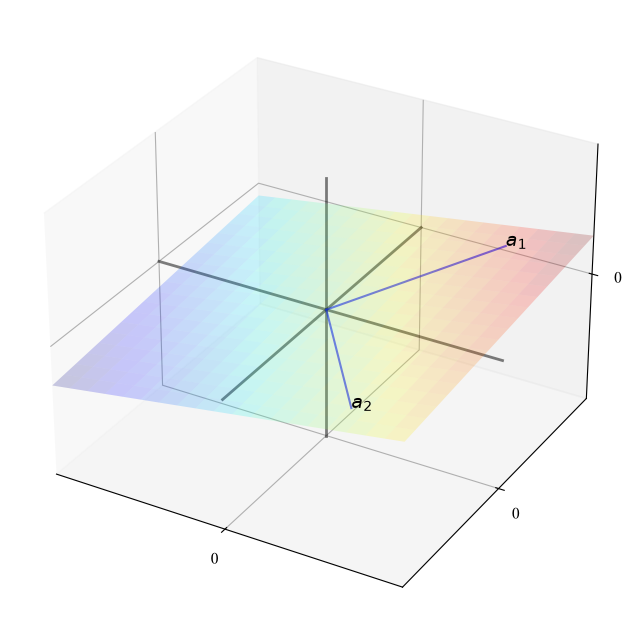

In [11]:
ax = plt.figure(figsize=(10, 8)).add_subplot(projection='3d')

x_min, x_max = -5, 5
y_min, y_max = -5, 5

α, β = 0.2, 0.1

ax.set(xlim=(x_min, x_max), ylim=(x_min, x_max), zlim=(x_min, x_max),
       xticks=(0,), yticks=(0,), zticks=(0,))

gs = 3
z = np.linspace(x_min, x_max, gs)
x = np.zeros(gs)
y = np.zeros(gs)
ax.plot(x, y, z, 'k-', lw=2, alpha=0.5)
ax.plot(z, x, y, 'k-', lw=2, alpha=0.5)
ax.plot(y, z, x, 'k-', lw=2, alpha=0.5)


# 固定线性函数，生成平面
def f(x, y):
    return α * x + β * y

# 向量位置，按坐标
x_coords = np.array((3, 3))
y_coords = np.array((4, -4))
z = f(x_coords, y_coords)
for i in (0, 1):
    ax.text(x_coords[i], y_coords[i], z[i], f'$a_{i+1}$', fontsize=14)

# 连接向量的线
for i in (0, 1):
    x = (0, x_coords[i])
    y = (0, y_coords[i])
    z = (0, f(x_coords[i], y_coords[i]))
    ax.plot(x, y, z, 'b-', lw=1.5, alpha=0.6)


# 绘制平面
grid_size = 20
xr2 = np.linspace(x_min, x_max, grid_size)
yr2 = np.linspace(y_min, y_max, grid_size)
x2, y2 = np.meshgrid(xr2, yr2)
z2 = f(x2, y2)
ax.plot_surface(x2, y2, z2, rstride=1, cstride=1, cmap=cm.jet,
                linewidth=0, antialiased=True, alpha=0.2)
plt.show()

#### 示例

如果 $A$ 只包含一个向量 $a_1 \in \mathbb R ^2$，那么它的张成空间只是 $a_1$ 的标量倍数，即通过 $a_1$ 和原点的唯一直线。

如果 $A = \{e_1, e_2, e_3\}$ 由 $\mathbb R ^3$ 的*标准基向量*组成，即

$$
e_1 :=
\begin{bmatrix}
     1 \\
     0 \\
     0
\end{bmatrix}
, \quad
e_2 :=
\begin{bmatrix}
     0 \\
     1 \\
     0
\end{bmatrix}
, \quad
e_3 :=
\begin{bmatrix}
     0 \\
     0 \\
     1
\end{bmatrix}
$$

那么 $A$ 的张成就是整个 $\mathbb R^3$，因为对于任意的 $x = (x_1, x_2, x_3) \in \mathbb R^3$，我们可以写成

$$
x = x_1 e_1 + x_2 e_2 + x_3 e_3
$$

现在考虑 $A_0 = \{e_1, e_2, e_1 + e_2\}$。

如果 $y = (y_1, y_2, y_3)$ 是这些向量的任意线性组合，那么 $y_3 = 0$（请验证）。

因此 $A_0$ 不能张成整个 $\mathbb R ^3$。

(la_li)=
### 线性无关

```{index} single: Vectors; Linear Independence
```

在实际应用中，我们经常需要找到一组能够张成较大空间的向量。这样做的好处是，我们可以用这少数几个向量的线性组合来表示更多的向量。

要使一组向量能张成较大的空间，这组向量需要满足一个重要条件 -- 线性无关。

具体来说，在$\mathbb R ^n$中的一组向量$A := \{a_1, \ldots, a_k\}$被称为

* *线性相关的*，如果$A$的某个真子集与$A$具有相同的张成空间。
* *线性无关的*，如果它不是线性相关的。

换句话说，一组向量如果没有一个向量对张成空间来说是多余的，则该组向量是线性无关的，否则就是线性相关的。

为了说明这个概念，让我们回到{ref}`图示<la_3dvec>`中的例子，其中$\mathbb R ^3$中的两个向量$\{a_1, a_2\}$张成了一个经过原点的平面。

如果我们添加第三个向量$a_3$，构成集合$\{a_1, a_2, a_3\}$，那么这个集合将是

* 线性相关的，如果$a_3$落在该平面上
* 线性无关的，否则

作为该概念的另一个例证，由于$\mathbb R ^n$可以由$n$个向量张成（参见上面关于标准基向量的讨论），因此在$\mathbb R ^n$中任何超过$n$个向量（即$m > n$个向量）的集合必定是线性相关的。

以下陈述与$A := \{a_1, \ldots, a_k\} \subset \mathbb R ^n$的线性无关性是等价的

1. 集合中的任何向量都不能写成其他向量的线性组合。
2. 如果对于标量$\beta_1, \ldots, \beta_k$，有$\beta_1 a_1 + \cdots + \beta_k a_k = 0$，那么$\beta_1 = \cdots = \beta_k = 0$。

（第一个表达式中的零指的是$\mathbb R ^n$的原点）

(la_unique_reps)=
### 唯一表示

线性独立向量集合的一个重要性质是唯一表示性：其张成空间中的每个向量都可以用唯一的一组系数来表示。

具体来说，假设$A := \{a_1, \ldots, a_k\} \subset \mathbb R ^n$是线性独立的，且

$$
y = \beta_1 a_1 + \cdots \beta_k a_k
$$

那么不存在其他系数序列$\gamma_1, \ldots, \gamma_k$能够得到相同的向量$y$。

事实上，如果我们同时有$y = \gamma_1 a_1 + \cdots \gamma_k a_k$，那么

$$
(\beta_1 - \gamma_1) a_1 + \cdots + (\beta_k - \gamma_k) a_k = 0
$$

由线性无关性可知，对所有的$i$都有$\gamma_i = \beta_i$。

## 矩阵

```{index} single: Linear Algebra; Matrices
```

矩阵是组织数据用于线性运算的一种简洁方式。

一个 $n \times k$ 矩阵是一个具有 $n$ 行和 $k$ 列的矩形数字数组 $A$：

$$
A =
\begin{bmatrix}
    a_{11} & a_{12} & \cdots & a_{1k} \\
    a_{21} & a_{22} & \cdots & a_{2k} \\
    \vdots & \vdots &  & \vdots \\
    a_{n1} & a_{n2} & \cdots & a_{nk}
\end{bmatrix}
$$

通常，矩阵中的数字表示线性方程组中的系数，正如本讲开始时所讨论的。

显然，当 $n = 1$ 或 $k = 1$ 时，矩阵 $A$ 也被称为向量。

在前一种情况下，$A$ 被称为*行向量*，而在后一种情况下被称为*列向量*。

如果 $n = k$，则 $A$ 被称为*方阵*。

将每个 $a_{ij}$ 替换为 $a_{ji}$ 所形成的矩阵被称为 $A$ 的*转置*，记作 $A'$ 或 $A^{\top}$。

如果 $A = A'$，则 $A$ 被称为*对称矩阵*。

对于方阵 $A$，形如 $a_{ii}$ 的 $i$ 个元素（其中 $i=1,\ldots,n$）被称为*主对角线*。

如果只有主对角线上的元素非零，则 $A$ 被称为*对角矩阵*。

如果除了是对角矩阵外，主对角线上的每个元素都等于1，则 $A$ 被称为*单位矩阵*，记作 $I$。

### 矩阵运算

```{index} single: Matrix; Operations
```

与向量一样，矩阵也定义了许多代数运算。

标量乘法和加法是向量情况的直接推广：

$$
\gamma A =
\gamma
\begin{bmatrix}
a_{11} &  \cdots & a_{1k} \\
    \vdots & \vdots  & \vdots \\
    a_{n1} &  \cdots & a_{nk}
\end{bmatrix} :=
\begin{bmatrix}
    \gamma a_{11} & \cdots & \gamma a_{1k} \\
    \vdots & \vdots & \vdots \\
    \gamma a_{n1} & \cdots & \gamma a_{nk}
\end{bmatrix}
$$

以及

$$
A + B =
\begin{bmatrix}
    a_{11} & \cdots & a_{1k} \\
    \vdots & \vdots & \vdots \\
    a_{n1} & \cdots & a_{nk}
\end{bmatrix} +
\begin{bmatrix}
    b_{11} & \cdots & b_{1k} \\
    \vdots & \vdots & \vdots \\
    b_{n1} & \cdots & b_{nk}
\end{bmatrix} :=
\begin{bmatrix}
    a_{11} + b_{11} &  \cdots & a_{1k} + b_{1k} \\
    \vdots & \vdots & \vdots \\
    a_{n1} + b_{n1} &  \cdots & a_{nk} + b_{nk}
\end{bmatrix}
$$

在后一种情况下，矩阵必须具有相同的形状才能使定义有意义。

我们还有一个*相乘*两个矩阵的约定。

矩阵乘法的规则推广了上面讨论的内积的概念。

并且其设计使得乘法能够很好地配合基本线性运算。

如果$A$和$B$是两个矩阵，那么它们的乘积$A B$的第$i,j$个元素是由$A$的第$i$行与$B$的第$j$列的内积得到的。

有许多教程可以帮助你理解这个运算，比如[这个](https://www.mathsisfun.com/algebra/matrix-multiplying.html)，或者[维基百科页面](https://en.wikipedia.org/wiki/Matrix_multiplication)上的讨论。

如果$A$是$n \times k$矩阵，$B$是$j \times m$矩阵，那么要使$A$和$B$可以相乘，我们需要$k = j$，且得到的矩阵$A B$是$n \times m$的。

作为可能最重要的特例，考虑将$n \times k$矩阵$A$与$k \times 1$列向量$x$相乘。

根据前面的规则，这会得到一个$n \times 1$列向量

```{math}
:label: la_atx

A x =
\begin{bmatrix}
    a_{11} &  \cdots & a_{1k} \\
    \vdots & \vdots  & \vdots \\
    a_{n1} &  \cdots & a_{nk}
\end{bmatrix}
\begin{bmatrix}
    x_{1}  \\
    \vdots  \\
    x_{k}
\end{bmatrix} :=
\begin{bmatrix}
    a_{11} x_1 + \cdots + a_{1k} x_k \\
    \vdots \\
    a_{n1} x_1 + \cdots + a_{nk} x_k
\end{bmatrix}
```

```{note}
矩阵乘法不满足交换律，也就是说，$A B$ 和 $B A$ 的结果通常是不同的。
```

另一个重要的特殊情况是单位矩阵。

你应该验证如果 $A$ 是 $n \times k$ 矩阵且 $I$ 是 $k \times k$ 单位矩阵，那么 $AI = A$。

如果 $I$ 是 $n \times n$ 单位矩阵，那么 $IA = A$。

### NumPy中的矩阵

```{index} single: Matrix; Numpy
```

NumPy数组也被用作矩阵，并且对所有标准矩阵运算都有快速、高效的函数和方法[^fn_mdt]。

你可以通过元组的元组（或列表的列表）手动创建它们，如下所示

In [12]:
A = ((1, 2),
     (3, 4))

type(A)

tuple

In [13]:
A = np.array(A)

type(A)

numpy.ndarray

In [14]:
A.shape

(2, 2)

`shape` 属性是一个表示行数和列数的元组 --- 更多讨论请参见[这里](https://python-programming.quantecon.org/numpy.html#shape-and-dimension)。

要获取 `A` 的转置，可以使用 `A.transpose()` 或更简单的 `A.T`。

有许多便捷的函数可用于创建常见矩阵（零矩阵、全1矩阵等）--- 参见[这里](https://python-programming.quantecon.org/numpy.html#creating-arrays)。

由于运算默认按元素执行，标量乘法和加法的语法具有非常自然

In [15]:
A = np.identity(3)
B = np.ones((3, 3))
2 * A

array([[2., 0., 0.],
       [0., 2., 0.],
       [0., 0., 2.]])

In [16]:
A + B

array([[2., 1., 1.],
       [1., 2., 1.],
       [1., 1., 2.]])

矩阵相乘我们使用`@`符号。

具体来说，`A @ B`表示矩阵乘法，而`A * B`表示元素逐个相乘。

更多讨论请参见[这里](https://python-programming.quantecon.org/numpy.html#matrix-multiplication)。

(la_linear_map)=
### 矩阵作为映射

```{index} single: Matrix; Maps
```

每个$n \times k$矩阵$A$都可以被视为一个函数$f(x) = Ax$，该函数将$x \in \mathbb R ^k$映射到$y = Ax \in \mathbb R ^n$。

这类函数具有一个特殊性质：它们是*线性的*。

如果对于所有的$x, y \in \mathbb R ^k$和所有标量$\alpha, \beta$，一个函数$f \colon \mathbb R ^k \to \mathbb R ^n$满足：

$$
f(\alpha x + \beta y) = \alpha f(x) + \beta f(y)
$$

则称该函数为*线性*函数。

你可以验证，当$b$为零向量时，函数$f(x) = A x + b$满足这个性质，而当$b$非零时则不满足。

事实上，[已知](https://en.wikipedia.org/wiki/Linear_map#Matrices)$f$是线性的当且仅当存在矩阵$A$使得对所有的$x$都有$f(x) = Ax$。

## 求解方程组

```{index} single: Matrix; Solving Systems of Equations
```

再次回顾方程组{eq}`la_se`。

如果我们比较{eq}`la_se`和{eq}`la_atx`，我们可以看到{eq}`la_se`现在可以更方便地写成

```{math}
:label: la_se2

y = Ax
```

我们面临的问题是确定一个向量$x \in \mathbb R ^k$来解{eq}`la_se2`，其中$y$和$A$是已知的。

这是一个更一般问题的特例：找到一个$x$使得$y = f(x)$。

给定任意函数$f$和一个$y$，是否总是存在一个$x$使得$y = f(x)$？

如果存在，它是否总是唯一的？

这两个问题的答案都是否定的，如下图所示

findfont: Failed to find font weight normal, now using 600.


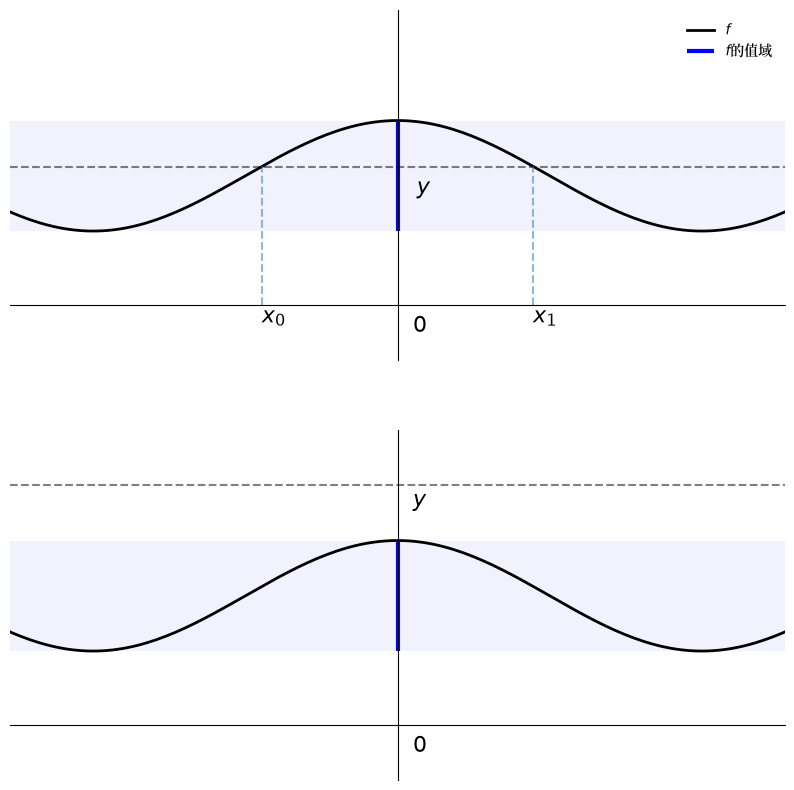

In [17]:
def f(x):
    return 0.6 * np.cos(4 * x) + 1.4


xmin, xmax = -1, 1
x = np.linspace(xmin, xmax, 160)
y = f(x)
ya, yb = np.min(y), np.max(y)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

for ax in axes:
    # Set the axes through the origin
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_position('zero')
    for spine in ['right', 'top']:
        ax.spines[spine].set_color('none')

    ax.set(ylim=(-0.6, 3.2), xlim=(xmin, xmax),
           yticks=(), xticks=())

    ax.plot(x, y, 'k-', lw=2, label='$f$')
    ax.fill_between(x, ya, yb, facecolor='blue', alpha=0.05)
    ax.vlines([0], ya, yb, lw=3, color='blue', label='$f$的值域')
    ax.text(0.04, -0.3, '$0$', fontsize=16)

ax = axes[0]

ax.legend(loc='upper right', frameon=False)
ybar = 1.5
ax.plot(x, x * 0 + ybar, 'k--', alpha=0.5)
ax.text(0.05, 0.8 * ybar, '$y$', fontsize=16)
for i, z in enumerate((-0.35, 0.35)):
    ax.vlines(z, 0, f(z), linestyle='--', alpha=0.5)
    ax.text(z, -0.2, f'$x_{i}$', fontsize=16)

ax = axes[1]

ybar = 2.6
ax.plot(x, x * 0 + ybar, 'k--', alpha=0.5)
ax.text(0.04, 0.91 * ybar, '$y$', fontsize=16)

plt.show()

在第一个图中，由于函数不是一一对应的，存在多个解，而
在第二个图中，由于$y$在函数$f$的值域之外，所以没有解。

我们能否对{eq}`la_se2`中的$A$施加条件来避免这些问题？

在这种情况下，最重要的是要认识到表达式$Ax$对应于$A$的列的线性组合。

具体来说，如果$a_1, \ldots, a_k$是$A$的列，那么

$$
Ax = x_1 a_1 + \cdots + x_k a_k
$$

因此，$f(x) = Ax$的值域恰好是$A$的列的张成空间。

我们希望值域足够大，以包含任意的$y$。

你可能记得，我们希望张成空间足够大的条件是{ref}`线性独立<la_li>`。

一个令人高兴的事实是，$A$的列的线性独立性也能给我们唯一性。

确实，根据我们{ref}`之前的讨论 <la_unique_reps>`，如果$\{a_1, \ldots, a_k\}$是线性无关的，且$y = Ax = x_1 a_1 + \cdots + x_k a_k$，那么不存在$z \not= x$满足$y = Az$。

### 方阵的情况

让我们讨论更多细节，首先从$A$是$n \times n$矩阵的情况开始。

这是我们熟悉的方程个数等于未知数个数的情况。

对于任意的$y \in \mathbb R ^n$，我们希望找到唯一的$x \in \mathbb R ^n$使得$y = Ax$。

根据上面的观察，如果$A$的列向量是线性无关的，那么它们的张成空间，也就是函数$f(x) = Ax$的值域，就是整个$\mathbb R ^n$。

因此总是存在$x$使得$y = Ax$。

而且，这个解是唯一的。

特别地，以下陈述是等价的：

1. $A$的列向量是线性无关的。
1. 对于任意$y \in \mathbb R ^n$，方程$y = Ax$有唯一解。

列向量线性独立的性质有时被表述为具有*满秩列*。

#### 逆矩阵

```{index} single: Matrix; Inverse
```

我们能给出某种形式的解吗？

如果$y$和$A$是标量且$A \not= 0$，那么解为$x = A^{-1} y$。

在矩阵的情况下也有类似的表达式。

特别地，如果方阵$A$具有满秩列，那么它就有一个乘法*逆矩阵*$A^{-1}$，具有性质$A A^{-1} = A^{-1} A = I$。

因此，如果我们用$A^{-1}$左乘等式$y = Ax$的两边，就得到$x = A^{-1} y$。

这就是我们要找的解。

#### 行列式

```{index} single: Matrix; Determinants
```

每个方阵都有一个与之唯一对应的数值，这个数值被称为矩阵的*行列式*。行列式的具体计算方法可以在[这里](https://en.wikipedia.org/wiki/Determinant)找到。

如果矩阵$A$的行列式不为零，我们就说$A$是*非奇异的*。

关于行列式最重要的事实可能是：$A$是非奇异的，当且仅当$A$具有满列秩。

这为我们提供了一个有用的单一数值，用来概括一个方阵是否可逆。

### 行数多于列数

这是$n \times k$的情况，其中$n > k$。

这种情况在许多场合都非常重要，尤其是在线性回归中（其中$n$是观测数量，$k$是解释变量的数量）。

对于任意的$y \in \mathbb R ^n$，我们寻找一个$x \in \mathbb R ^k$使得$y = Ax$。

在这种情况下，解的存在性是极不可能的。

在不失一般性的情况下，让我们着重讨论$A$的列向量线性独立的情况。

由此可知，$A$的列向量张成的空间是$\mathbb R ^n$中的一个$k$维子空间。

这个张成空间不太"可能"包含任意的 $y \in \mathbb R ^n$。

要理解原因，请回顾{ref}`上图<la_3dvec>`，其中 $k=2$ 且 $n=3$。

想象一个任意选择的 $y \in \mathbb R ^3$，位于这个三维空间中的某处。

$y$ 落在 $\{a_1, a_2\}$ 的张成空间中（即通过这些点的二维平面）的可能性有多大？

从某种意义上说，这个可能性一定很小，因为这个平面的"厚度"为零。

因此，在 $n > k$ 的情况下，我们通常会放弃寻求精确解。

然而，我们仍然可以寻求最佳近似解，例如，找到一个使距离 $\| y - Ax\|$ 尽可能小的 $x$。

要解决这个问题，可以使用微积分或正交投影理论。

解为 $\hat x = (A'A)^{-1}A'y$ --- 参见[这些笔记](https://python.quantecon.org/_static/lecture_specific/linear_algebra/course_notes.pdf)的第3章。

### 列数多于行数

这是 $n \times k$ 的情况，其中 $n < k$，所以方程数少于未知数。

在这种情况下，要么没有解，要么有无穷多个解 --- 换句话说，解永远不会是唯一的。

例如，考虑 $k=3$ 且 $n=2$ 的情况。

因此，$A$ 的列由 $\mathbb R ^2$ 中的3个向量组成。

这组向量永远不可能线性独立，因为可以找到两个向量就能张成 $\mathbb R ^2$。

（例如，使用标准基向量）

由此可知，其中一列是其他两列的线性组合。

例如，假设 $a_1 = \alpha a_2 + \beta a_3$。

那么如果 $y = Ax = x_1 a_1 + x_2 a_2 + x_3 a_3$，我们也可以写成

$$
y
= x_1 (\alpha a_2 + \beta a_3) + x_2 a_2 + x_3 a_3
= (x_1 \alpha + x_2) a_2 + (x_1 \beta + x_3) a_3
$$

换句话说，解不具有唯一性。

### 使用SciPy求解线性方程

```{index} single: Linear Algebra; SciPy
```

下面展示如何使用SciPy的`linalg`子模块求解线性方程。

所有这些程序都是经过时间检验和高度优化的FORTRAN代码的Python前端接口

In [18]:
A = ((1, 2), (3, 4))
A = np.array(A)
y = np.ones((2, 1))  # 列向量
det(A)  # 检查A是非奇异的，因此是可逆的

np.float64(-2.0)

In [19]:
A_inv = inv(A)  # 计算逆矩阵
A_inv

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

In [20]:
x = A_inv @ y  # 解
A @ x          # 应该等于y

array([[1.],
       [1.]])

In [21]:
solve(A, y)  # 产生相同的解

array([[-1.],
       [ 1.]])

请注意我们可以通过`inv(A) @ y`或使用`solve(A, y)`来求解$x = A^{-1} y$。

后一种方法使用了不同的算法（LU分解），该算法在数值上更加稳定，因此几乎总是应优先选用。

如果需要求解最小二乘解$\hat x = (A'A)^{-1}A'y$，可以使用`scipy.linalg.lstsq(A, y)`。

(la_eigen)=
## {index}`特征值 <single: Eigenvalues>`和{index}`特征向量 <single: Eigenvectors>`

```{index} single: Linear Algebra; Eigenvalues
```

```{index} single: Linear Algebra; Eigenvectors
```

设$A$是一个$n \times n$的方阵。

如果$\lambda$是一个标量，且$v$是$\mathbb R ^n$中的非零向量，满足

$$
A v = \lambda v
$$

则我们称$\lambda$是$A$的*特征值*，而$v$是*特征向量*。

换句话说，特征向量是那些经过线性变换$f(x) = Ax$后，方向保持不变、只是长度发生变化的向量。

下图中，蓝色箭头表示两个特征向量，红色箭头表示它们经过变换后的结果。

可以看到，每个特征向量$v$经过变换后得到的$Av$都与原向量指向相同的方向，只是长度改变了

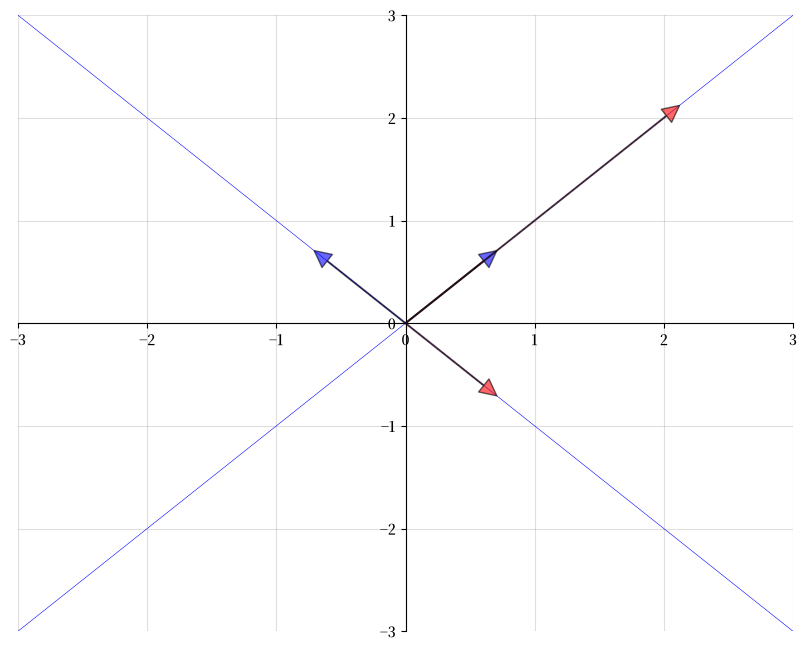

In [22]:
A = ((1, 2),
     (2, 1))
A = np.array(A)
evals, evecs = eig(A)
evecs = evecs[:, 0], evecs[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))

# 设置通过原点的坐标轴
for spine in ['left', 'bottom']:
    ax.spines[spine].set_position('zero')
for spine in ['right', 'top']:
    ax.spines[spine].set_color('none')
ax.grid(alpha=0.4)

xmin, xmax = -3, 3
ymin, ymax = -3, 3
ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax))

# 绘制每个特征向量
for v in evecs:
    ax.annotate('', xy=v, xytext=(0, 0),
                arrowprops=dict(facecolor='blue',
                shrink=0,
                alpha=0.6,
                width=0.5))

# 绘制每个特征向量的像
for v in evecs:
    v = A @ v
    ax.annotate('', xy=v, xytext=(0, 0),
                arrowprops=dict(facecolor='red',
                shrink=0,
                alpha=0.6,
                width=0.5))

# 绘制它们所在的直线
x = np.linspace(xmin, xmax, 3)
for v in evecs:
    a = v[1] / v[0]
    ax.plot(x, a * x, 'b-', lw=0.4)

plt.show()

特征值方程等价于 $(A - \lambda I) v = 0$，只有当 $A - \lambda I$ 的列向量线性相关时，才存在非零解 $v$。

这反过来又等价于行列式为零。

因此，要找到所有特征值，我们可以寻找使 $A - \lambda I$ 的行列式为零的 $\lambda$ 值。

这个问题可以表示为求解一个关于 $\lambda$ 的 $n$ 次多项式的根。

这进而意味着在复平面上存在 $n$ 个解，尽管有些可能是重复的。

关于方阵 $A$ 的特征值，有以下一些重要性质：

1. $A$ 的行列式等于所有特征值的乘积。
1. $A$ 的迹（主对角线上元素的和）等于所有特征值的和。
1. 如果 $A$ 是对称矩阵，那么它的所有特征值都是实数。
1. 如果$A$是可逆的，且$\lambda_1, \ldots, \lambda_n$是它的特征值，那么$A^{-1}$的特征值是$1/\lambda_1, \ldots, 1/\lambda_n$。

第一个陈述的一个推论是：矩阵可逆当且仅当它的所有特征值都不为零。

使用SciPy，我们可以按如下方式求解矩阵的特征值和特征向量

In [23]:
A = ((1, 2),
     (2, 1))

A = np.array(A)
evals, evecs = eig(A)
evals

array([ 3.+0.j, -1.+0.j])

In [24]:
evecs

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

注意 `evecs` 的*列*是特征向量。

由于特征向量的任意标量倍数都是具有相同特征值的特征向量（可以验证），eig 程序会将每个特征向量的长度归一化为1。

### 广义特征值

有时考虑*广义特征值问题*很有用，即对给定的矩阵 $A$ 和 $B$，寻找广义特征值 $\lambda$ 和特征向量 $v$，使得

$$
A v = \lambda B v
$$

这可以通过 SciPy 中的 `scipy.linalg.eig(A, B)` 求解。

当然，如果 $B$ 是方阵且可逆，我们可以将广义特征值问题转化为普通特征值问题 $B^{-1} A v = \lambda v$，但情况并非总是如此。

## 进阶概念

我们通过简要介绍几个其他重要概念来结束讨论。

### 级数展开

```{index} single: Linear Algebra; Series Expansions
```

回顾几何级数的常用求和公式，即

如果 $|a| < 1$，那么 $\sum_{k=0}^{\infty} a^k = (1 - a)^{-1}$。

这个思想在矩阵环境中有一个推广形式。

(la_mn)=
#### 矩阵范数

```{index} single: Linear Algebra; Matrix Norms
```

设 $A$ 为方阵，定义

$$
\| A \| := \max_{\| x \| = 1} \| A x \|
$$

右边的范数是普通的向量范数，而左边的范数是*矩阵范数*——在这种情况下，称为*谱范数*。

例如，对于方阵 $S$，条件 $\| S \| < 1$ 意味着 $S$ 是*压缩的*，即它将所有向量拉向原点[^cfn]。

(la_neumann)=
#### {index}`诺伊曼定理 <single: Neumann's Theorem>`

```{index} single: Linear Algebra; Neumann's Theorem
```

设 $A$ 为方阵，令 $A^k := A A^{k-1}$，其中 $A^1 := A$。

换句话说，$A^k$ 是 $A$ 的 $k$ 次幂。

诺伊曼定理指出：如果对某个 $\| A^k \| < 1$

$k \in \mathbb{N}$，则 $I - A$ 是可逆的，且

```{math}
:label: la_neumann

(I - A)^{-1} = \sum_{k=0}^{\infty} A^k
```

(la_neumann_remarks)=
#### {index}`谱半径 <single: Spectral Radius>`

```{index} single: Linear Algebra; Spectral Radius
```

Gelfand公式告诉我们，对于任意方阵 $A$，

$$
\rho(A) = \lim_{k \to \infty} \| A^k \|^{1/k}
$$

这里 $\rho(A)$ 是*谱半径*，定义为 $\max_i |\lambda_i|$，其中 $\{\lambda_i\}_i$ 是 $A$ 的特征值集合。

作为Gelfand公式的结果，如果所有特征值的模都严格小于1，
则存在一个 $k$ 使得 $\| A^k \| < 1$。

在这种情况下，{eq}`la_neumann` 是有效的。

### {index}`正定矩阵 <single: Positive Definite Matrices>`

```{index} single: Linear Algebra; Positive Definite Matrices
```

设 $A$ 是一个 $n \times n$ 对称矩阵。

我们称 $A$ 是

1. 如果对于每个 $x \in \mathbb R ^n \setminus \{0\}$，都有 $x' A x > 0$，则称矩阵为*正定的*
1. 如果对于每个 $x \in \mathbb R ^n$，都有 $x' A x \geq 0$，则称矩阵为*半正定的*或*非负定的*

负定和半负定矩阵有类似的定义。

值得注意的是，如果 $A$ 是正定的，那么它的所有特征值都严格为正，因此 $A$ 是可逆的（且其逆矩阵也是正定的）。

(la_mcalc)=
### 线性和二次型的求导

```{index} single: Linear Algebra; Differentiating Linear and Quadratic Forms
```

以下公式在许多经济学场景中都很有用。设

* $z, x$ 和 $a$ 都是 $n \times 1$ 向量
* $A$ 是 $n \times n$ 矩阵
* $B$ 是 $m \times n$ 矩阵，$y$ 是 $m \times 1$ 向量

则

1. $\frac{\partial a' x}{\partial x} = a$
1. $\frac{\partial A x}{\partial x} = A'$
1. $\frac{\partial x'A x}{\partial x} = (A + A') x$
1. $\frac{\partial y'B z}{\partial y} = B z$
1. $\frac{\partial y'B z}{\partial B} = y z'$

下面的{ref}`la_ex1`要求你应用这些公式。

### 延伸阅读

`scipy.linalg`子模块的文档可以在[这里](https://docs.scipy.org/doc/scipy/reference/linalg.html)找到。

[计量经济学理论](https://johnstachurski.net/emet.html)的第2章和第3章包含了与上述内容类似的线性代数讨论，并附有已解答的练习题。

如果你不介意稍微抽象的方法，{cite}`Janich1994`是一本不错的中级线性代数教材。

## 练习

```{exercise-start}
:label: la_ex1
```

设$x$是一个给定的$n \times 1$向量，考虑以下问题

$$
v(x) =  \max_{y,u} \left\{ - y'P y - u' Q u \right\}
$$

受限于线性约束

$$
y = A x + B u
$$

其中

* $P$是一个$n \times n$矩阵，$Q$是一个$m \times m$矩阵
* $A$是一个$n \times n$矩阵，$B$是一个$n \times m$矩阵
* $P$和$Q$都是对称且半正定的

($y$ 和 $u$ 的维度必须是多少才能使这成为一个合理的问题？)

解决这个问题的一种方法是构建拉格朗日函数

$$
\mathcal L = - y' P y - u' Q u + \lambda' \left[A x + B u - y\right]
$$

其中 $\lambda$ 是一个 $n \times 1$ 的拉格朗日乘子向量。

尝试应用上面给出的关于二次型和线性型求导的公式，得到关于 $y, u$ 的最大化和关于 $\lambda$ 的最小化的一阶条件。

证明这些条件意味着：

1. $\lambda = - 2 P y$。
1. $u$ 的最优选择满足 $u = - (Q + B' P B)^{-1} B' P A x$。
1. 函数 $v$ 满足 $v(x) = - x' \tilde P x$，其中 $\tilde P = A' P A - A'P B (Q + B'P B)^{-1} B' P A$。

正如我们将看到的，在经济学背景下，拉格朗日乘子通常是影子价格。

```{note}

如果我们不关心拉格朗日乘数，我们可以将约束条件代入目标函数，然后仅对$u$最大化$-(Ax + Bu)'P (Ax + Bu) - u' Q u$。你可以验证这会得到相同的最大值。
```

```{exercise-end}
```

```{solution-start} la_ex1
:class: dropdown
```

我们有一个优化问题：

$$
v(x) = \max_{y,u} \{ -y'Py - u'Qu \}
$$

满足约束条件：

$$
y = Ax + Bu
$$

其中基本条件为：

- $P$是一个对称且半正定的$n \times n$矩阵
- $Q$是一个对称且半正定的$m \times m$矩阵
- $A$是一个$n \times n$矩阵
- $B$是一个$n \times m$矩阵

相关的拉格朗日函数是：

$$
L = -y'Py - u'Qu + \lambda' \lbrack Ax + Bu - y \rbrack
$$

**第1步：**

对拉格朗日方程关于y求导并令其导数等于零得到：

$$
\frac{ \partial L}{\partial y} = - (P + P') y - \lambda = - 2 P y - \lambda = 0 \:,
$$

因为P是对称的。

因此，关于y的拉格朗日方程最大化的一阶条件意味着

$$
\lambda = -2 Py \:
$$

**第2步.**

对拉格朗日方程关于u求导并令其导数等于零得到

$$
\frac{ \partial L}{\partial u} = - (Q + Q') u - B'\lambda = - 2Qu + B'\lambda = 0 \:
$$

代入$\lambda = -2 P y$得到

$$
Qu + B'Py = 0 \:
$$

将线性约束$y = Ax + Bu$代入上式得到

$$
Qu + B'P(Ax + Bu) = 0
$$

$$
(Q + B'PB)u + B'PAx = 0
$$

这是关于u的拉格朗日方程最大化的一阶条件。

因此，u的最优选择必须满足

$$
u = -(Q + B'PB)^{-1}B'PAx \:,
$$

这是由拉格朗日方程的一阶条件定义得出的。

**第3步.**

将约束代入目标函数，重写我们的问题，得到

$$
v(x) = \max_{u} \{ -(Ax+ Bu)'P(Ax+Bu) - u'Qu \} \:
$$

由于我们知道u的最优选择满足$u = -(Q + B'PB)^{-1}B'PAx$，那么

$$

v(x) =  -(Ax+ B u)'P(Ax+B u) - u'Q u  \,\,\,\, 其中 \,\,\,\, u = -(Q + B'PB)^{-1}B'PAx
$$

计算函数

$$
\begin{aligned}
v(x) &=  -(Ax+ B u)'P(Ax+Bu) - u'Q u \\
&= -(x'A' + u'B')P(Ax+Bu) - u'Q u \\
&= - x'A'PAx - u'B'PAx - x'A'PBu - u'B'PBu - u'Qu \\
&= - x'A'PAx - 2u'B'PAx - u'(Q + B'PB) u
\end{aligned}
$$

为简化起见，令 $S := (Q + B'PB)^{-1} B'PA$，则 $u = -Sx$。

对于第二项 $- 2u'B'PAx$，

$$
\begin{aligned}
-2u'B'PAx &= -2 x'S'B'PAx  \\
& = 2 x'A'PB( Q + B'PB)^{-1} B'PAx
\end{aligned}
$$

注意到项 $(Q + B'PB)^{-1}$ 是对称的，因为 P 和 Q 都是对称的。

对于第三项 $- u'(Q + B'PB) u$，

$$
\begin{aligned}
-u'(Q + B'PB) u &= - x'S' (Q + B'PB)Sx \\
&= -x'A'PB(Q + B'PB)^{-1}B'PAx
\end{aligned}
$$

因此，第二项和第三项的和为
$x'A'PB(Q + B'PB)^{-1}B'PAx$。

这意味着

$$
\begin{aligned}
 v(x) &= - x'A'PAx - 2u'B'PAx - u'(Q + B'PB) u\\
 &= - x'A'PAx + x'A'PB(Q + B'PB)^{-1}B'PAx \\
 &= -x'[A'PA - A'PB(Q + B'PB)^{-1}B'PA] x
\end{aligned}
$$

因此，优化问题的解
$v(x) = -x' \tilde{P}x$ 遵循上述结果，其中
$\tilde{P} := A'PA - A'PB(Q + B'PB)^{-1}B'PA$

```{solution-end}
```

[^fn_mdt]: 虽然NumPy中定义了专门的矩阵数据类型，但使用普通的NumPy数组更为标准。
参见[此讨论](https://python-programming.quantecon.org/numpy.html#matrix-multiplication)。

[^cfn]: 假设 $\|S \| < 1$。取任意非零向量 $x$，令 $r := \|x\|$。我们有 $\| Sx \| = r \| S (x/r) \| \leq r \| S \| < r = \| x\|$。因此每个点都被拉向原点。